# CMPE 255 Assignment 1 — Part 2
## Experiment 05: Data Science Skills Mastery Lab

### AI-Assisted Replication of Instructor Project 05

This notebook implements a compact version of the Data Science Skills Mastery Lab from the instructor's `data_science_examples` repository.

The goal is to demonstrate several common data science skills in one complete workflow.

### Skills Demonstrated

- Data loading
- Data quality checking
- Exploratory data analysis
- Feature scaling
- Train/test splitting
- Classification modeling
- Cross-validation
- Model comparison
- Feature importance
- PCA visualization
- Result interpretation

### Adaptation

Instead of building a large skills platform, this notebook focuses on demonstrating the core data science skills directly through a reproducible machine learning project.

## 1. Business Understanding

This experiment uses a breast cancer diagnostic dataset.

The machine learning task is to classify each sample as:

- Malignant
- Benign

The main goal of this notebook is educational.

The focus is not to create a medical system, but to demonstrate a complete collection of common data science skills using one structured dataset.

The results should not be used for real medical decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

from sklearn.decomposition import PCA

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Understanding

The Breast Cancer Wisconsin dataset is included with scikit-learn.

It contains numerical measurements calculated from images of breast cell samples.

The target variable contains two classes:

- 0 = Malignant
- 1 = Benign

Using a built-in dataset makes the experiment easy to reproduce without requiring an external file.

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(
    cancer.target,
    name="target"
)

data = X.copy()

data["target"] = y

print("Dataset shape:", data.shape)

print("\nNumber of features:", X.shape[1])

print("\nTarget names:")
print(cancer.target_names)

data.head()

Dataset shape: (569, 31)

Number of features: 30

Target names:
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Missing values:")
print(data.isnull().sum().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

print("\nData types:")
print(data.dtypes.value_counts())

Missing values:
0

Duplicate rows:
0

Data types:
float64    30
int64       1
Name: count, dtype: int64


### Data Quality Result

The dataset is already clean and contains numerical input features.

Even when a dataset appears clean, checking for missing values, duplicate rows, and incorrect data types is still an important part of a data science workflow.

In [4]:
target_counts = (
    data["target"]
    .value_counts()
    .sort_index()
)

target_counts.index = [
    "Malignant",
    "Benign"
]

target_counts

,count
Malignant,212
Benign,357


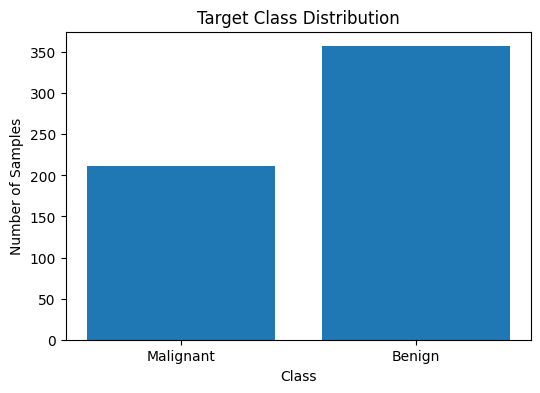

In [5]:
plt.figure(figsize=(6, 4))

plt.bar(
    target_counts.index,
    target_counts.values
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [6]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

data[selected_features].describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16


### Exploratory Analysis

The features are measured on very different numerical scales.

For example, area values are much larger than smoothness values.

This is important because some machine learning models are sensitive to feature scale.

Standardization will therefore be included in the modeling workflow where appropriate.

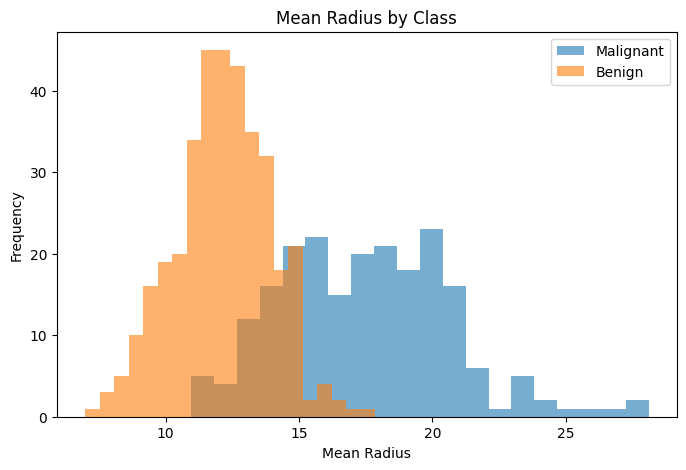

In [7]:
malignant = data[
    data["target"] == 0
]["mean radius"]

benign = data[
    data["target"] == 1
]["mean radius"]

plt.figure(figsize=(8, 5))

plt.hist(
    malignant,
    bins=20,
    alpha=0.6,
    label="Malignant"
)

plt.hist(
    benign,
    bins=20,
    alpha=0.6,
    label="Benign"
)

plt.title("Mean Radius by Class")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.legend()

plt.show()

The distributions show that mean radius contains useful information for separating the two classes.

However, classification should not rely on only one feature.

The machine learning models will use all available input features.

## 3. Data Preparation

The dataset is divided into training and testing sets.

- 80% is used for training
- 20% is used for testing

Stratification is used so that both sets maintain a similar class distribution.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 455
Testing samples: 114


## 4. Modeling

Three classification models are compared:

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest

Logistic Regression and KNN use standardized features.

Random Forest does not require feature scaling in the same way, so it is trained directly on the original feature values.

In [9]:
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])


knn_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])


random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [10]:
logistic_model.fit(
    X_train,
    y_train
)

knn_model.fit(
    X_train,
    y_train
)

random_forest_model.fit(
    X_train,
    y_train
)

print(
    "All models trained successfully."
)

All models trained successfully.


In [11]:
def evaluate_model(
    model_name,
    model,
    X_test,
    y_test
):

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [12]:
model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        logistic_model,
        X_test,
        y_test
    )
)

model_results.append(
    evaluate_model(
        "KNN",
        knn_model,
        X_test,
        y_test
    )
)

model_results.append(
    evaluate_model(
        "Random Forest",
        random_forest_model,
        X_test,
        y_test
    )
)

results_table = pd.DataFrame(
    model_results
)

results_table.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,KNN,0.9561,0.9589,0.9722,0.9655
2,Random Forest,0.9561,0.9589,0.9722,0.9655


## 5. Cross-Validation

A single train/test split gives only one estimate of model performance.

Cross-validation evaluates a model using several different parts of the training data.

This gives a more stable view of model performance.

Five-fold cross-validation is used in this experiment.

In [13]:
models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Random Forest": random_forest_model
}

cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV Accuracy": scores.mean(),
        "CV Standard Deviation": scores.std()
    })

cv_table = pd.DataFrame(
    cv_results
)

cv_table.round(4)

,Model,Mean CV Accuracy,CV Standard Deviation
0,Logistic Regression,0.9802,0.0128
1,KNN,0.9670,0.0209
2,Random Forest,0.9604,0.0192


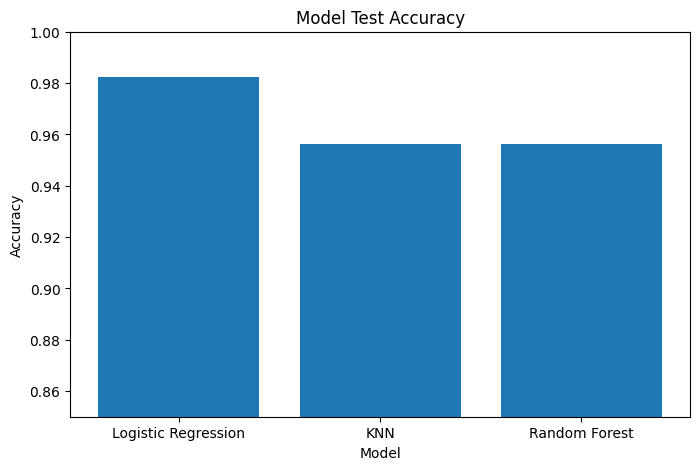

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_table["Model"],
    results_table["Accuracy"]
)

plt.ylim(
    0.85,
    1.00
)

plt.title(
    "Model Test Accuracy"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

In [15]:
best_model_name = (
    results_table
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model = models[
    best_model_name
]

best_predictions = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

print(
    "Best model:",
    best_model_name
)

print(
    "\nConfusion Matrix:"
)

print(cm)

Best model: Logistic Regression

Confusion Matrix:
[[41  1]
 [ 1 71]]


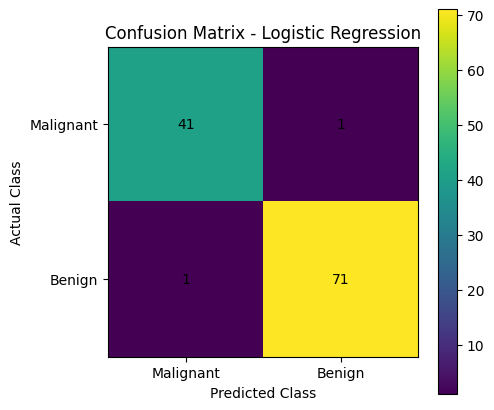

In [16]:
plt.figure(figsize=(5, 5))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.yticks(
    [0, 1],
    ["Malignant", "Benign"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(10)
)

feature_importance

,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


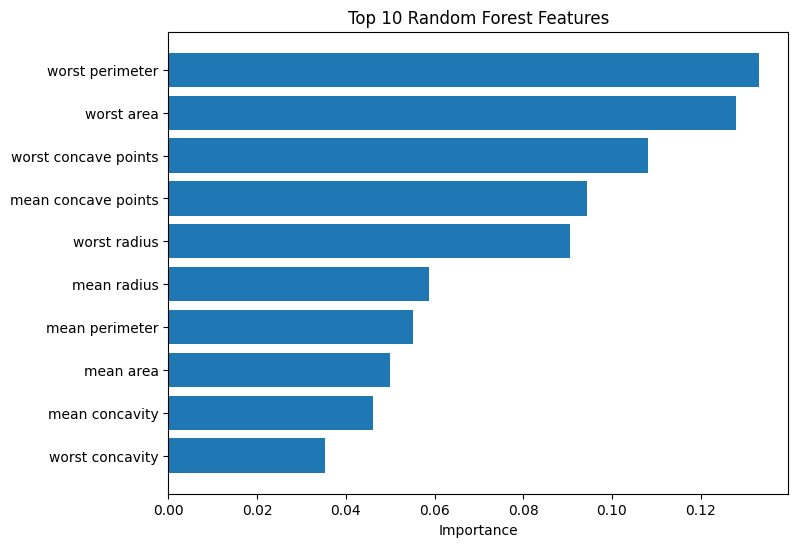

In [18]:
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title(
    "Top 10 Random Forest Features"
)

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

## 6. PCA Visualization

The original dataset contains 30 input features, which cannot be directly shown in a two-dimensional graph.

Principal Component Analysis, or PCA, can reduce the standardized features to two components for visualization.

PCA is used here only for visualization.

The classification models above were trained using the original features.

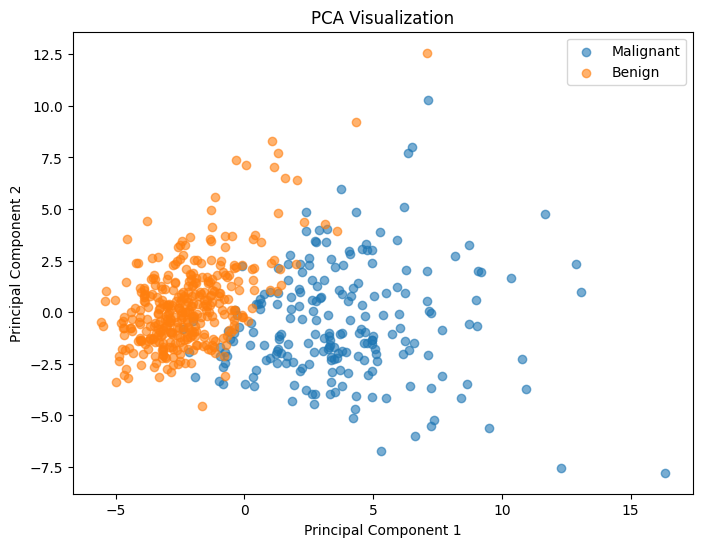

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_data = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Target": y
})

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_data[
        pca_data["Target"] == 0
    ]["PC1"],
    pca_data[
        pca_data["Target"] == 0
    ]["PC2"],
    alpha=0.6,
    label="Malignant"
)

plt.scatter(
    pca_data[
        pca_data["Target"] == 1
    ]["PC1"],
    pca_data[
        pca_data["Target"] == 1
    ]["PC2"],
    alpha=0.6,
    label="Benign"
)

plt.title(
    "PCA Visualization"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.legend()

plt.show()

## 7. Results Interpretation

All three classification models achieved strong performance on the test set.

### Model Comparison

- **Logistic Regression:** Accuracy = 0.9825, F1 = 0.9861
- **KNN:** Accuracy = 0.9561, F1 = 0.9655
- **Random Forest:** Accuracy = 0.9561, F1 = 0.9655

Logistic Regression achieved the best test performance.

It correctly classified 112 of the 114 test samples.

The confusion matrix was:

- 41 malignant samples correctly classified
- 71 benign samples correctly classified
- 1 malignant sample incorrectly classified
- 1 benign sample incorrectly classified

### Cross-Validation

Five-fold cross-validation also supported the Logistic Regression result.

The mean cross-validation accuracies were:

- Logistic Regression: 0.9802
- KNN: 0.9670
- Random Forest: 0.9604

This is useful because the strong Logistic Regression result was not observed only on one test split.

### Feature Importance

The Random Forest feature importance analysis identified features such as worst perimeter, worst area, worst concave points, mean concave points, and worst radius as important predictors.

Feature importance describes how useful a feature was to the model. It should not be interpreted as proof that a feature causes a diagnosis.

### PCA Visualization

The PCA visualization reduced the 30 input features to two components for visualization.

The malignant and benign samples show different patterns in the two-dimensional space, although some overlap remains.

PCA was used only for visualization. The classification models were trained using the original input features.

## 8. Data Science Skills Demonstrated

This experiment combined several reusable data science skills in one workflow.

### Data Understanding

- Loaded a structured dataset
- Checked dataset size
- Examined the target variable
- Reviewed feature statistics

### Data Quality

- Checked missing values
- Checked duplicate rows
- Reviewed data types

### Exploratory Analysis

- Examined class distribution
- Compared feature distributions
- Identified differences in feature scale

### Data Preparation

- Created train/test sets
- Used stratification
- Standardized features where needed
- Used machine learning pipelines

### Modeling

- Logistic Regression
- K-Nearest Neighbors
- Random Forest

### Evaluation

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion matrix
- Five-fold cross-validation

### Interpretation

- Model comparison
- Random Forest feature importance
- PCA visualization

## 9. Limitations

This experiment is designed to demonstrate data science skills rather than create a real medical diagnostic system.

Important limitations include:

- The dataset is relatively small.
- Only three machine learning models were compared.
- The project does not include detailed model tuning.
- PCA is used only for visualization.
- Feature importance does not prove causation.
- Machine learning predictions should not replace professional medical judgment.

A real medical machine learning system would require much more data, external validation, careful testing, and expert review.

## 10. Conclusion

This experiment implemented a compact Data Science Skills Mastery Lab using the Breast Cancer Wisconsin dataset.

The dataset contained 569 samples and 30 input features.

The workflow demonstrated skills in:

- Data understanding
- Data quality checking
- Exploratory analysis
- Data preparation
- Feature scaling
- Classification
- Cross-validation
- Model evaluation
- Feature importance
- PCA visualization

Three classification models were compared.

Logistic Regression achieved the best test performance with an accuracy of approximately 98.25% and an F1 score of approximately 98.61%.

It correctly classified 112 of the 114 test samples.

Five-fold cross-validation also produced a mean accuracy of approximately 98.02% for Logistic Regression.

Random Forest feature importance and PCA were used to provide additional ways to understand the dataset and model behavior.

The experiment demonstrates how multiple data science skills can be combined into one organized and reproducible workflow.

The results are educational and should not be used for real medical decisions.